In [1]:
import os
import shutil
from PIL import Image

input_dir = '/kaggle/input/datasets/alizaysarfraz/soil-type/Soil type'
clean_dir = '/kaggle/working/clean_soil_data'

print("Wiping old directory...")
if os.path.exists(clean_dir):
    shutil.rmtree(clean_dir)

bad_files = 0
good_files = 0

print("converting all images...\n")

for root, dirs, files in os.walk(input_dir):
    for file in files:
        file_path = os.path.join(root, file)
        
        # Skipped system files that might cause issues immediately
        if file.startswith('.') or file.endswith('.ini'):
            continue
            
        relative_path = os.path.relpath(root, input_dir)
        dest_folder = os.path.join(clean_dir, relative_path)
        os.makedirs(dest_folder, exist_ok=True)
        
        try:
            # Opening the image with PIL
            with Image.open(file_path) as img:
                # Forcing conversion to pure RGB 
                rgb_im = img.convert('RGB')
                
                # Force the new file to be a .jpg
                new_filename = os.path.splitext(file)[0] + '.jpg'
                dest_path = os.path.join(dest_folder, new_filename)
                
                # Save as a standard JPEG
                rgb_im.save(dest_path, 'JPEG')
                good_files += 1
                
        except Exception as e:
            print(f"Busted File Caught & Removed -> {file} | Reason: {e}")
            bad_files += 1

print(f"\n--- Sanitization Complete ---")
print(f"Pure JPEGs created: {good_files}")
print(f"Corrupted/Invalid files destroyed: {bad_files}")

Wiping old directory and starting fresh...
Sanitizing and converting all images for Arvia...


--- Sanitization Complete ---
Pure JPEGs created: 7000
Corrupted/Invalid files destroyed: 0


2026-03-14 09:52:24.877504: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773481944.894466     225 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773481944.899594     225 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773481944.912932     225 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773481944.912946     225 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773481944.912948     225 computation_placer.cc:177] computation placer alr

Indexing the dataset
Found 7000 files belonging to 7 classes.
Using 5600 files for training.


I0000 00:00:1773481955.668506     225 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1773481955.673700     225 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 7000 files belonging to 7 classes.
Using 1400 files for validation.

The dataset map is updated.

Found 7 exact classes: ['Alluvial_Soil', 'Arid_Soil', 'Black_Soil', 'Laterite_Soil', 'Mountain_Soil', 'Red_Soil', 'Yellow_Soil']

Building VGG16 Model

Starting training on GPU
Epoch 1/10


I0000 00:00:1773481959.654597     291 service.cc:152] XLA service 0x7cdfbc00cd10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773481959.654643     291 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1773481959.654650     291 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1773481960.086048     291 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/175 ━━━━━━━━━━━━━━━━━━━━ 42:32 15s/step - accuracy: 0.1875 - loss: 14.4111

I0000 00:00:1773481972.681826     291 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


175/175 ━━━━━━━━━━━━━━━━━━━━ 63s 276ms/step - accuracy: 0.6118 - loss: 3.5160 - val_accuracy: 0.9307 - val_loss: 0.2562
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 41s 236ms/step - accuracy: 0.9245 - loss: 0.2986 - val_accuracy: 0.9421 - val_loss: 0.2399
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 42s 240ms/step - accuracy: 0.9591 - loss: 0.1483 - val_accuracy: 0.9557 - val_loss: 0.1922
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 41s 237ms/step - accuracy: 0.9740 - loss: 0.1089 - val_accuracy: 0.9593 - val_loss: 0.1869
Epoch 5/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 42s 239ms/step - accuracy: 0.9794 - loss: 0.0804 - val_accuracy: 0.9614 - val_loss: 0.1873
Epoch 6/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 41s 237ms/step - accuracy: 0.9800 - loss: 0.0898 - val_accuracy: 0.9636 - val_loss: 0.2018
Epoch 7/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 41s 237ms/step - accuracy: 0.9817 - loss: 0.0986 - val_accuracy: 0.9679 - val_loss: 0.1679
Epoch 8/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 41s 237ms/step - accuracy: 0.9896 - loss: 0.0414 - val


Success! Model saved to: /kaggle/working/ArviaApp_Soil_Model_v1.h5


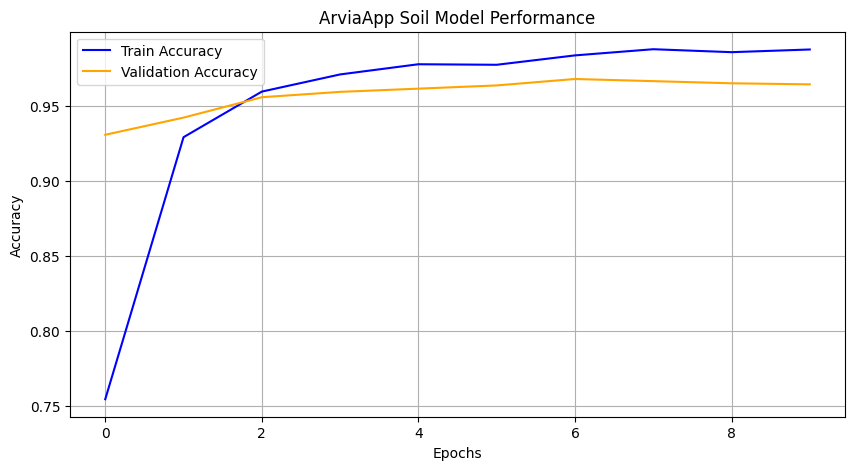

Accuracy curve saved to: /kaggle/working/accuracy_curve.png

Generating predictions for the confusion matrix


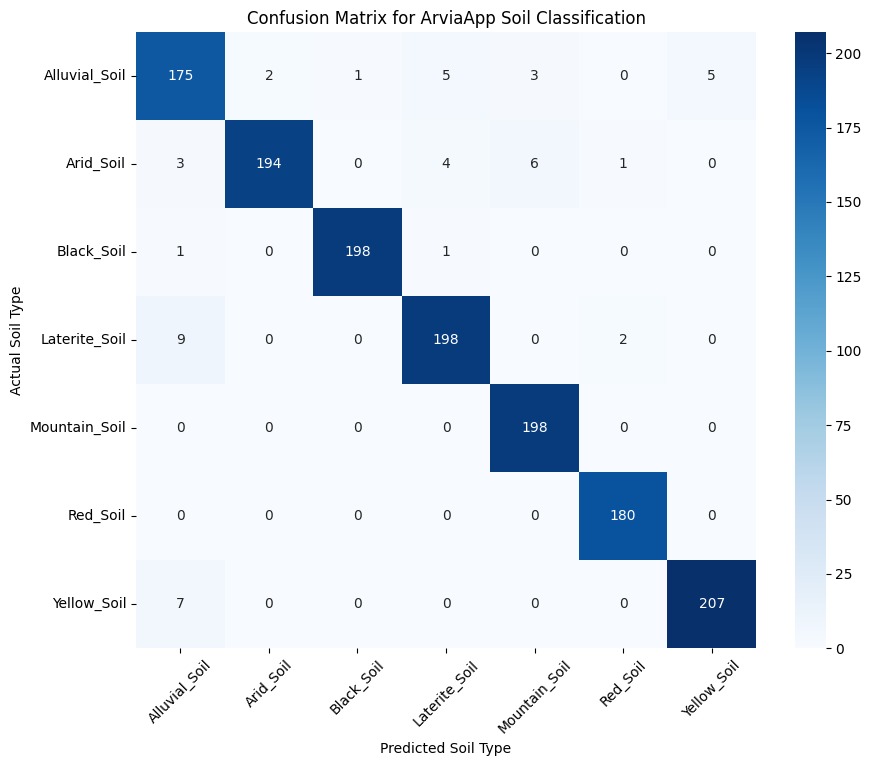

Confusion matrix saved to: /kaggle/working/confusion_matrix.png


In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Flatten, Dropout, Lambda
from tensorflow.keras import optimizers
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix

#Dataset 
dataset_dir = '/kaggle/working/clean_soil_data' 

print("Indexing the dataset")
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(224, 224),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(224, 224),
    batch_size=32
)
print("\nThe dataset map is updated.")

# Dynamically counting classes to prevent InvalidArgumentError
class_names = train_ds.class_names
num_classes = len(class_names)
print(f"\nFound {num_classes} exact classes: {class_names}")

#Building the Model
print("\nBuilding VGG16 Model")
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False 

model = Sequential([
    Input(shape=(224, 224, 3)), # Fixes the UserWarning
    Lambda(preprocess_input),
    base_model,
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax') # Dynamically matches your folder count
])

model.compile(
    optimizer=optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#Training the Model
print("\nStarting training on GPU")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

#Saving the Model
model_path = '/kaggle/working/ArviaApp_Soil_Model_v1.h5'
model.save(model_path)
print(f"\nSuccess! Model saved to: {model_path}")

#Plotting the Results
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('ArviaApp Soil Model Performance')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.savefig('/kaggle/working/accuracy_curve.png', dpi=300, bbox_inches='tight')
plt.show()
print("Accuracy curve saved to: /kaggle/working/accuracy_curve.png")

#Creating Confusion Matrix
print("\nGenerating predictions for the confusion matrix")

y_true = []
y_pred_probs = []

for images, labels in val_ds:
    y_true.extend(labels.numpy())
    preds = model.predict(images, verbose=0)
    y_pred_probs.extend(preds)

y_true = np.array(y_true)
y_pred = np.argmax(np.array(y_pred_probs), axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, 
            yticklabels=class_names)

plt.title('Confusion Matrix for ArviaApp Soil Classification')
plt.ylabel('Actual Soil Type')
plt.xlabel('Predicted Soil Type')
plt.xticks(rotation=45) 

plt.savefig('/kaggle/working/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print("Confusion matrix saved to: /kaggle/working/confusion_matrix.png")

144744/144744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Loading model...


Analyzing soil...
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


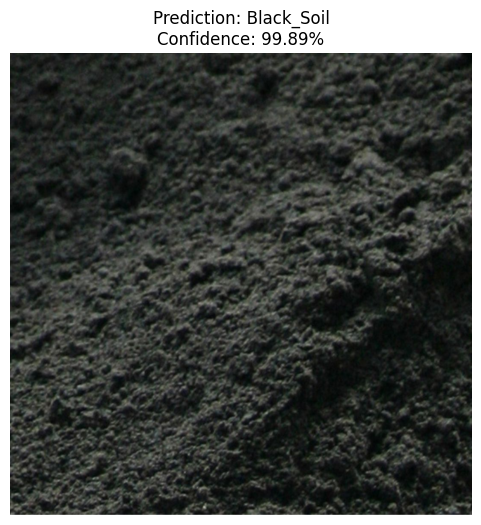

In [5]:
#for image testing
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input
import matplotlib.pyplot as plt

#Path to the saved model
model_path = '/kaggle/working/ArviaApp_Soil_Model_v1.h5'

#image link
image_url = 'https://meadowvillesmartsoils.ca/cdn/shop/files/black-soil-bulk-delivery.jpg?v=1708964703' 

try:
    print("Downloading test image..")
    test_image_path = tf.keras.utils.get_file('test_soil_img.jpg', origin=image_url)

    print("Loading model...")
    model = tf.keras.models.load_model(
        model_path, 
        custom_objects={'preprocess_input': preprocess_input}
    )


    class_names = ['Alluvial_Soil', 'Arid_Soil', 'Black_Soil', 'Laterite_Soil', 'Mountain_Soil', 'Red_Soil', 'Yellow_Soil']

    #Loading and formatting the image
    print("Analyzing soil...")
    img = image.load_img(test_image_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) 

    #Making the prediction
    predictions = model.predict(img_array)
    predicted_class_index = np.argmax(predictions[0])
    predicted_class_name = class_names[predicted_class_index]
    confidence = predictions[0][predicted_class_index] * 100

    #Showing the result
    plt.figure(figsize=(6, 6))
    plt.imshow(image.load_img(test_image_path)) 
    plt.title(f"Prediction: {predicted_class_name}\nConfidence: {confidence:.2f}%")
    plt.axis('off')
    plt.show()

except Exception as e:
    print(f"Error loading the image: {e}")